# Music Recommendation System Using PySpark

**Assignment part:** Part B - Recommendation System Using Big Data

This notebook builds a music recommendation system using Apache Spark / PySpark. The system uses user listening history to recommend songs that a selected user has not listened to yet.

**Dataset choice:** Last.fm 1K users listening-history dataset. The public dataset contains user, timestamp, artist, and song listening events collected through the Last.fm API. A smaller sample is generated automatically if the real dataset is not present, so the notebook can still be tested.

**Recommendation method:** Collaborative filtering using Spark MLlib Alternating Least Squares, also called ALS. Listening count is treated as implicit feedback: if a user played a song many times, the model treats it as a stronger preference.

## How to do the assignment

1. Select a music listening dataset with user-song interactions.
2. Load the dataset using PySpark.
3. Clean missing users, artists, and song names.
4. Convert raw listening events into user-song play counts.
5. Convert string user IDs and song IDs into numeric indexes required by ALS.
6. Train an ALS collaborative filtering model.
7. Evaluate the recommendation quality using held-out user-song interactions.
8. Generate top-N music recommendations for a selected user.
9. Interpret results, limitations, and future improvements.

## 1. Install and import required libraries

Run this cell first. In Google Colab or a fresh Jupyter environment it will install PySpark if it is missing.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = ['pyspark', 'pandas', 'matplotlib']

for package_name in REQUIRED_PACKAGES:
    if importlib.util.find_spec(package_name) is None:
        print(f'Installing {package_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

print('Environment is ready.')

Environment is ready.


In [2]:
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml.feature import StringIndexer
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

PROJECT_DIR = Path.cwd()
LOCAL_JAVA_HOME = PROJECT_DIR / '.jdk' / 'jdk-17.0.19+10' / 'Contents' / 'Home'
SPARK_LOCAL_DIR = PROJECT_DIR / 'spark-temp'
MPLCONFIG_DIR = PROJECT_DIR / '.matplotlib'
SPARK_LOCAL_DIR.mkdir(exist_ok=True)
MPLCONFIG_DIR.mkdir(exist_ok=True)

if LOCAL_JAVA_HOME.exists():
    os.environ.setdefault('JAVA_HOME', str(LOCAL_JAVA_HOME))
    os.environ['PATH'] = f"{LOCAL_JAVA_HOME / 'bin'}:{os.environ.get('PATH', '')}"

os.environ.setdefault('SPARK_LOCAL_IP', '127.0.0.1')
os.environ.setdefault('PYSPARK_PIN_THREAD', 'false')
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIG_DIR))

spark = (
    SparkSession.builder
    .master('local[2]')
    .appName('LastFMMusicRecommendation')
    .config('spark.driver.host', '127.0.0.1')
    .config('spark.driver.bindAddress', '127.0.0.1')
    .config('spark.driver.memory', '4g')
    .config('spark.executor.memory', '2g')
    .config('spark.sql.shuffle.partitions', '4')
    .config('spark.local.dir', str(SPARK_LOCAL_DIR))
    .config('spark.ui.enabled', 'false')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('WARN')
spark.range(1).count()
print('Spark version:', spark.version)

Spark version: 4.0.2


## 2. Dataset setup

For the final submission, use the full Last.fm 1K dataset that you downloaded.

- Dataset page: https://github.com/eifuentes/lastfm-dataset-1K
- Your local folder: `/Users/sahanpaymedia/Downloads/lastfm-dataset-1K`
- Listening file: `userid-timestamp-artid-artname-traid-traname.tsv`
- Profile file: `userid-profile.tsv`
- Optional smaller file for easier testing: `lastfm-dataset-50.snappy.parquet`

If no dataset file is found in either the project `data` folder or your Downloads folder, the notebook creates a small sample listening-history dataset. Use that only for testing the workflow. For the actual assignment submission, mention and use the real Last.fm dataset link.

In [3]:
import csv
import random
from datetime import datetime, timedelta
from urllib.request import urlretrieve

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

LOCAL_LASTFM_DIR = Path('/Users/sahanpaymedia/Downloads/lastfm-dataset-1K')

PARQUET_PATH = DATA_DIR / 'lastfm-dataset-50.snappy.parquet'
TSV_PATH = DATA_DIR / 'userid-timestamp-artid-artname-traid-traname.tsv'
TSV_ZIP_PATH = DATA_DIR / 'userid-timestamp-artid-artname-traid-traname.tsv.zip'
PROFILE_PATH = DATA_DIR / 'userid-profile.tsv'
LOCAL_TSV_PATH = LOCAL_LASTFM_DIR / 'userid-timestamp-artid-artname-traid-traname.tsv'
LOCAL_PROFILE_PATH = LOCAL_LASTFM_DIR / 'userid-profile.tsv'
SAMPLE_PATH = DATA_DIR / 'sample_lastfm_listens.csv'

DOWNLOAD_SAMPLE_PARQUET = False
MAX_RAW_ROWS = 1000000  # Safer for local laptops. Set to None only when you want to process the full 2.4 GB file.

if DOWNLOAD_SAMPLE_PARQUET and not PARQUET_PATH.exists():
    sample_url = 'https://github.com/eifuentes/lastfm-dataset-1K/releases/download/v1.0/lastfm-dataset-50.snappy.parquet'
    print('Downloading sample parquet file...')
    urlretrieve(sample_url, PARQUET_PATH)
    print('Downloaded:', PARQUET_PATH)

def create_sample_lastfm_csv(path):
    random.seed(42)
    users = [f'user_{i:03d}' for i in range(1, 31)]
    tracks = [
        ('artist_001', 'Taylor Swift', 'track_001', 'Anti Hero', 'pop'),
        ('artist_002', 'Dua Lipa', 'track_002', 'Levitating', 'pop'),
        ('artist_003', 'Ariana Grande', 'track_003', 'Positions', 'pop'),
        ('artist_004', 'Coldplay', 'track_004', 'Yellow', 'rock'),
        ('artist_005', 'Linkin Park', 'track_005', 'Numb', 'rock'),
        ('artist_006', 'Imagine Dragons', 'track_006', 'Believer', 'rock'),
        ('artist_007', 'Kendrick Lamar', 'track_007', 'Humble', 'hiphop'),
        ('artist_008', 'Drake', 'track_008', 'Gods Plan', 'hiphop'),
        ('artist_009', 'Travis Scott', 'track_009', 'Sicko Mode', 'hiphop'),
        ('artist_010', 'Daft Punk', 'track_010', 'One More Time', 'electronic'),
        ('artist_011', 'Calvin Harris', 'track_011', 'Summer', 'electronic'),
        ('artist_012', 'Avicii', 'track_012', 'Levels', 'electronic'),
        ('artist_013', 'Arctic Monkeys', 'track_013', 'Do I Wanna Know', 'indie'),
        ('artist_014', 'Tame Impala', 'track_014', 'Let It Happen', 'indie'),
        ('artist_015', 'The Strokes', 'track_015', 'Last Nite', 'indie'),
        ('artist_016', 'The Weeknd', 'track_016', 'Blinding Lights', 'rnb'),
        ('artist_017', 'SZA', 'track_017', 'Good Days', 'rnb'),
        ('artist_018', 'Frank Ocean', 'track_018', 'Pink White', 'rnb'),
    ]
    genres = ['pop', 'rock', 'hiphop', 'electronic', 'indie', 'rnb']
    base_time = datetime(2024, 1, 1, 8, 0, 0)
    rows = []

    for user_index, user_id in enumerate(users):
        preferred_genre = genres[user_index % len(genres)]
        for listen_number in range(80):
            if random.random() < 0.72:
                candidate_tracks = [track for track in tracks if track[4] == preferred_genre]
            else:
                candidate_tracks = tracks
            artist_id, artist_name, track_id, track_name, genre = random.choice(candidate_tracks)
            timestamp = (base_time + timedelta(minutes=len(rows))).strftime('%Y-%m-%dT%H:%M:%SZ')
            rows.append({
                'user_id': user_id,
                'timestamp': timestamp,
                'artist_id': artist_id,
                'artist_name': artist_name,
                'track_id': track_id,
                'track_name': track_name,
            })

    with path.open('w', newline='', encoding='utf-8') as output_file:
        writer = csv.DictWriter(output_file, fieldnames=['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name'])
        writer.writeheader()
        writer.writerows(rows)

    print(f'Created sample dataset: {path} with {len(rows)} rows')

## 3. Load the data using Spark

This section supports four input options:

1. Parquet Last.fm subset in the project `data` folder.
2. Extracted Last.fm TSV file in the project `data` folder.
3. Your downloaded Last.fm folder in `/Users/sahanpaymedia/Downloads/lastfm-dataset-1K`.
4. Auto-generated sample CSV fallback.

In [4]:
EXPECTED_COLUMNS = ['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name']

listen_schema = T.StructType([
    T.StructField('user_id', T.StringType(), True),
    T.StructField('timestamp', T.StringType(), True),
    T.StructField('artist_id', T.StringType(), True),
    T.StructField('artist_name', T.StringType(), True),
    T.StructField('track_id', T.StringType(), True),
    T.StructField('track_name', T.StringType(), True),
])

def read_lastfm_tsv(path):
    return (
        spark.read.schema(listen_schema)
        .option('sep', '\t')
        .option('header', False)
        .option('mode', 'PERMISSIVE')
        .csv(str(path))
    )

if PARQUET_PATH.exists():
    dataset_source = PARQUET_PATH
    print('Loading parquet dataset:', dataset_source)
    listens = spark.read.parquet(str(dataset_source))
elif TSV_PATH.exists():
    dataset_source = TSV_PATH
    print('Loading TSV dataset from project data folder:', dataset_source)
    listens = read_lastfm_tsv(dataset_source)
elif LOCAL_TSV_PATH.exists():
    dataset_source = LOCAL_TSV_PATH
    print('Loading full Last.fm 1K TSV dataset from Downloads:', dataset_source)
    listens = read_lastfm_tsv(dataset_source)
elif TSV_ZIP_PATH.exists():
    import zipfile

    print('Extracting TSV zip file:', TSV_ZIP_PATH)
    with zipfile.ZipFile(TSV_ZIP_PATH) as zip_file:
        tsv_member = next(name for name in zip_file.namelist() if name.endswith('.tsv'))
        zip_file.extract(tsv_member, DATA_DIR)
        dataset_source = DATA_DIR / tsv_member

    listens = read_lastfm_tsv(dataset_source)
else:
    dataset_source = SAMPLE_PATH
    print('No real dataset found. Creating a small sample dataset for workflow testing.')
    create_sample_lastfm_csv(SAMPLE_PATH)
    listens = spark.read.option('header', True).csv(str(SAMPLE_PATH))

if MAX_RAW_ROWS is not None:
    listens = listens.limit(MAX_RAW_ROWS)
    print(f'Using only the first {MAX_RAW_ROWS:,} raw rows for a faster demo run.')

profile_source = LOCAL_PROFILE_PATH if LOCAL_PROFILE_PATH.exists() else PROFILE_PATH
if profile_source.exists():
    print('Loading user profile data:', profile_source)
    user_profiles = (
        spark.read.option('sep', '\t')
        .option('header', True)
        .csv(str(profile_source))
        .withColumnRenamed('#id', 'user_id')
    )
else:
    user_profiles = None
    print('No user profile file found. Continuing with listening events only.')

print('Dataset source:', dataset_source)
print('Columns:', listens.columns)
listens.show(5, truncate=False)

Loading full Last.fm 1K TSV dataset from Downloads: /Users/sahanpaymedia/Downloads/lastfm-dataset-1K/userid-timestamp-artid-artname-traid-traname.tsv
Using only the first 1,000,000 raw rows for a faster demo run.
Loading user profile data: /Users/sahanpaymedia/Downloads/lastfm-dataset-1K/userid-profile.tsv
Dataset source: /Users/sahanpaymedia/Downloads/lastfm-dataset-1K/userid-timestamp-artid-artname-traid-traname.tsv
Columns: ['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name']
+-----------+--------------------+------------------------------------+-----------+--------+------------------------------------------+
|user_id    |timestamp           |artist_id                           |artist_name|track_id|track_name                                |
+-----------+--------------------+------------------------------------+-----------+--------+------------------------------------------+
|user_000001|2009-05-04T23:08:57Z|f1b1cf71-bd35-4e99-8624-24a6e15f133a|Deep Dish  

## 4. Clean and preprocess the listening events

The raw data contains one row per listening event. For recommendation modelling, we remove unusable rows and create a stable `track_key` for each song.

In [5]:
missing_columns = [column for column in EXPECTED_COLUMNS if column not in listens.columns]
if missing_columns:
    raise ValueError(f'Missing expected columns: {missing_columns}')

timestamp_clean = F.regexp_replace(F.regexp_replace(F.col('timestamp'), 'T', ' '), 'Z$', '')
track_id_clean = F.when(
    (F.col('track_id').isNotNull()) & (F.length(F.trim(F.col('track_id'))) > 0),
    F.trim(F.col('track_id')),
)
fallback_track_key = F.concat_ws('::', F.lower(F.col('artist_name')), F.lower(F.col('track_name')))

listens_clean = (
    listens.select(*EXPECTED_COLUMNS)
    .withColumn('user_id', F.trim(F.col('user_id')))
    .withColumn('artist_id', F.trim(F.col('artist_id')))
    .withColumn('artist_name', F.trim(F.col('artist_name')))
    .withColumn('track_id', F.trim(F.col('track_id')))
    .withColumn('track_name', F.trim(F.col('track_name')))
    .withColumn('timestamp', F.to_timestamp(timestamp_clean))
    .where(F.col('user_id').isNotNull() & (F.length(F.col('user_id')) > 0))
    .where(F.col('artist_name').isNotNull() & (F.length(F.col('artist_name')) > 0))
    .where(F.col('track_name').isNotNull() & (F.length(F.col('track_name')) > 0))
    .withColumn('track_key', F.coalesce(track_id_clean, fallback_track_key))
    .dropDuplicates(['user_id', 'timestamp', 'artist_name', 'track_name'])
)

listens_clean.cache()

if user_profiles is not None:
    user_profiles_clean = (
        user_profiles.select('user_id', 'gender', 'age', 'country', 'registered')
        .withColumn('user_id', F.trim(F.col('user_id')))
        .withColumn('gender', F.trim(F.col('gender')))
        .withColumn('age', F.col('age').cast('int'))
        .withColumn('country', F.trim(F.col('country')))
        .withColumn('registered', F.to_date(F.col('registered'), 'MMM d, yyyy'))
        .where(F.col('user_id').isNotNull() & (F.length(F.col('user_id')) > 0))
    )
    user_profiles_clean.cache()
    listens_with_profile = listens_clean.join(user_profiles_clean, on='user_id', how='left')
    print('User profile rows:', user_profiles_clean.count())
else:
    user_profiles_clean = None
    listens_with_profile = listens_clean

listens_clean.show(5, truncate=False)

User profile rows: 992
+-----------+-------------------+------------------------------------+-----------------+------------------------------------+----------------------------------------+------------------------------------+
|user_id    |timestamp          |artist_id                           |artist_name      |track_id                            |track_name                              |track_key                           |
+-----------+-------------------+------------------------------------+-----------------+------------------------------------+----------------------------------------+------------------------------------+
|user_000001|2006-08-13 13:59:20|09a114d9-7723-4e14-b524-379697f6d2b5|Plaid & Bob Jaroc|c4633ab1-e715-477f-8685-afa5f2058e42|The Launching Of Big Face               |c4633ab1-e715-477f-8685-afa5f2058e42|
|user_000001|2006-08-13 14:03:29|09a114d9-7723-4e14-b524-379697f6d2b5|Plaid & Bob Jaroc|bc2765af-208c-44c5-b3b0-cf597a646660|Zn Zero                             

## 5. Initial inspection and exploratory analysis

These statistics show whether the dataset is large and rich enough for a recommendation system.

In [6]:
summary_rows = [
    ('listening_events', listens_clean.count()),
    ('unique_users', listens_clean.select('user_id').distinct().count()),
    ('unique_artists', listens_clean.select('artist_name').distinct().count()),
    ('unique_tracks', listens_clean.select('track_key').distinct().count()),
]

if user_profiles_clean is not None:
    summary_rows.extend([
        ('profile_users', user_profiles_clean.select('user_id').distinct().count()),
        ('profile_countries', user_profiles_clean.where(F.col('country').isNotNull() & (F.length(F.col('country')) > 0)).select('country').distinct().count()),
    ])

summary_df = spark.createDataFrame(summary_rows, ['metric', 'value'])
summary_df.show(truncate=False)

+-----------------+-------+
|metric           |value  |
+-----------------+-------+
|listening_events |1000000|
|unique_users     |41     |
|unique_artists   |23007  |
|unique_tracks    |159093 |
|profile_users    |992    |
|profile_countries|66     |
+-----------------+-------+



,artist_name,listen_events
0,Kanye West,27267
1,Dir En Grey,12006
2,ムック,7789
3,Radiohead,7157
4,Nine Inch Nails,6711
5,Muse,6052
6,雅-Miyavi-,6018
7,T.I.,5394
8,Akira Yamaoka,5028
9,Sloan,4993


,artist_name,track_name,listen_events
0,Kanye West,See You In My Nightmares,2069
1,Kanye West,Say You Will,2065
2,Kanye West,Heartless,2063
3,Kanye West,Love Lockdown,2062
4,Kanye West,Welcome To Heartbreak (Feat. Kid Cudi),2059
5,Kanye West,Coldest Winter,2052
6,Kanye West,Paranoid (Feat. Mr. Hudson),2051
7,Kanye West,Amazing (Feat. Young Jeezy),2049
8,Kanye West,Pinocchio Story (Freestyle Live From Singapore),2041
9,Kanye West,Bad News,2026


,country,users
0,United States,228
1,United Kingdom,126
2,Poland,50
3,Germany,36
4,Norway,35
5,Finland,32
6,Canada,32
7,Turkey,28
8,Italy,27
9,Sweden,24


/var/folders/b8/drwntrs511d5lpq2j_jdd6y00000gn/T/ipykernel_6642/3272905619.py:45: UserWarning: Glyph 38597 (\N{CJK UNIFIED IDEOGRAPH-96C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b8/drwntrs511d5lpq2j_jdd6y00000gn/T/ipykernel_6642/3272905619.py:45: UserWarning: Glyph 12512 (\N{KATAKANA LETTER MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b8/drwntrs511d5lpq2j_jdd6y00000gn/T/ipykernel_6642/3272905619.py:45: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b8/drwntrs511d5lpq2j_jdd6y00000gn/T/ipykernel_6642/3272905619.py:45: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/sahanpaymedia/Documents/Assignment BigData/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38597 (\N{CJK UNIFIED IDEOGRAPH-96C5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

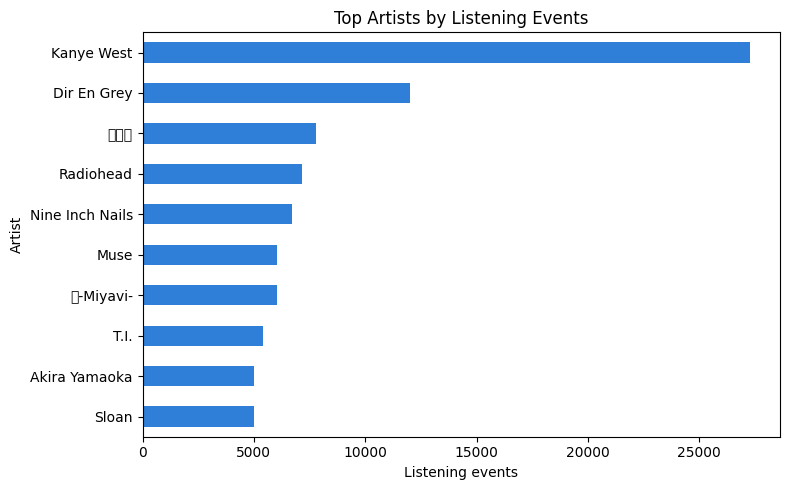

In [7]:
top_artists = (
    listens_clean.groupBy('artist_name')
    .agg(F.count('*').alias('listen_events'))
    .orderBy(F.desc('listen_events'))
    .limit(10)
    .toPandas()
)

top_tracks = (
    listens_clean.groupBy('artist_name', 'track_name')
    .agg(F.count('*').alias('listen_events'))
    .orderBy(F.desc('listen_events'))
    .limit(10)
    .toPandas()
)

if user_profiles_clean is not None:
    top_countries = (
        user_profiles_clean.where(F.col('country').isNotNull() & (F.length(F.col('country')) > 0))
        .groupBy('country')
        .agg(F.count('*').alias('users'))
        .orderBy(F.desc('users'))
        .limit(10)
        .toPandas()
    )
else:
    top_countries = pd.DataFrame(columns=['country', 'users'])

display(top_artists)
display(top_tracks)
if not top_countries.empty:
    display(top_countries)

ax = top_artists.sort_values('listen_events').plot(
    kind='barh',
    x='artist_name',
    y='listen_events',
    legend=False,
    figsize=(8, 5),
    color='#2f7ed8',
)
ax.set_title('Top Artists by Listening Events')
ax.set_xlabel('Listening events')
ax.set_ylabel('Artist')
plt.tight_layout()
plt.show()

## 6. Feature engineering for collaborative filtering

ALS requires three numeric columns: user index, item index, and preference. The preference score is based on how many times a user listened to a track. `log1p` reduces the effect of extremely high play counts.

In [8]:
play_counts = (
    listens_clean.groupBy('user_id', 'track_key', 'artist_name', 'track_name')
    .agg(F.count('*').alias('play_count'))
)

interactions = play_counts.withColumn('preference', F.log1p(F.col('play_count')).cast('float'))

active_users = (
    interactions.groupBy('user_id')
    .agg(F.count('*').alias('user_track_count'))
    .where(F.col('user_track_count') >= 3)
    .select('user_id')
)

popular_tracks = (
    interactions.groupBy('track_key')
    .agg(F.count('*').alias('track_user_count'))
    .where(F.col('track_user_count') >= 2)
    .select('track_key')
)

filtered_interactions = (
    interactions.join(active_users, on='user_id', how='inner')
    .join(popular_tracks, on='track_key', how='inner')
)

user_indexer = StringIndexer(inputCol='user_id', outputCol='user_idx', handleInvalid='skip')
track_indexer = StringIndexer(inputCol='track_key', outputCol='track_idx', handleInvalid='skip')

user_indexer_model = user_indexer.fit(filtered_interactions)
indexed_once = user_indexer_model.transform(filtered_interactions)

track_indexer_model = track_indexer.fit(indexed_once)
indexed = (
    track_indexer_model.transform(indexed_once)
    .withColumn('user_idx', F.col('user_idx').cast('int'))
    .withColumn('track_idx', F.col('track_idx').cast('int'))
    .select('user_id', 'user_idx', 'track_key', 'track_idx', 'artist_name', 'track_name', 'play_count', 'preference')
)

indexed.cache()
print('Model interactions:', indexed.count())
indexed.show(5, truncate=False)

Model interactions: 84633
+-----------+--------+------------------------------------+---------+---------------------+----------------------+----------+----------+
|user_id    |user_idx|track_key                           |track_idx|artist_name          |track_name            |play_count|preference|
+-----------+--------+------------------------------------+---------+---------------------+----------------------+----------+----------+
|user_000001|35      |3ca05a3e-6cac-4d57-b16f-a99a2861b2c0|4180     |Boards Of Canada     |Constants Are Changing|13        |2.6390574 |
|user_000001|35      |9b0d3374-7968-4844-9bac-8b9397eccd42|5169     |Boards Of Canada     |Sherbet Head          |13        |2.6390574 |
|user_000001|35      |736adf7b-c988-4177-bb93-9299e641db50|2814     |Boards Of Canada     |Chromakey Dreamcoat   |1         |0.6931472 |
|user_000001|35      |dba9158f-b56a-4611-b675-551538730a0a|25903    |Roni Size & Reprazent|Watching Windows      |1         |0.6931472 |
|user_000001|35

## 7. Train the ALS recommendation model

ALS learns hidden user preferences and hidden song characteristics from the user-song interaction matrix. Because listening events are implicit feedback, the model uses `implicitPrefs=True`.

In [9]:
train_data, test_data = indexed.randomSplit([0.8, 0.2], seed=42)

als = ALS(
    userCol='user_idx',
    itemCol='track_idx',
    ratingCol='preference',
    implicitPrefs=True,
    nonnegative=True,
    coldStartStrategy='drop',
    rank=8,
    maxIter=8,
    regParam=0.08,
    alpha=20.0,
    seed=42,
)

als_model = als.fit(train_data)
print('ALS model training complete.')

ALS model training complete.


## 8. Evaluate the model

For implicit feedback, RMSE is only a rough diagnostic because the model predicts preference strength, not explicit star ratings. Precision@K and hit rate are more useful because the system outputs a ranked recommendation list.

In [10]:
predictions = als_model.transform(test_data).dropna(subset=['prediction'])

if predictions.count() > 0:
    evaluator = RegressionEvaluator(
        metricName='rmse',
        labelCol='preference',
        predictionCol='prediction',
    )
    rmse = evaluator.evaluate(predictions)
    print(f'RMSE diagnostic: {rmse:.4f}')
else:
    print('No predictions available after cold-start filtering.')

K = 10
user_recommendations = als_model.recommendForAllUsers(K)

test_items = (
    test_data.select('user_idx', 'track_idx')
    .distinct()
    .groupBy('user_idx')
    .agg(F.collect_set('track_idx').alias('actual_items'))
)

ranking_eval = (
    user_recommendations.join(test_items, on='user_idx', how='inner')
    .withColumn('recommended_items', F.expr('transform(recommendations, item -> int(item.track_idx))'))
    .withColumn('hits', F.size(F.array_intersect(F.col('recommended_items'), F.col('actual_items'))))
    .withColumn('precision_at_k', F.col('hits') / F.lit(K))
    .withColumn('hit_rate_at_k', F.when(F.col('hits') > 0, F.lit(1.0)).otherwise(F.lit(0.0)))
)

metrics = ranking_eval.agg(
    F.avg('precision_at_k').alias('precision_at_10'),
    F.avg('hit_rate_at_k').alias('hit_rate_at_10'),
)

metrics.show(truncate=False)

RMSE diagnostic: 1.3045
+--------------------+-------------------+
|precision_at_10     |hit_rate_at_10     |
+--------------------+-------------------+
|0.024390243902439022|0.12195121951219512|
+--------------------+-------------------+



## 9. Generate recommendations for a selected user

This section selects an active user, shows some songs the user has already listened to, and recommends new songs by excluding songs already known to that user.

In [11]:
track_lookup = indexed.select('track_idx', 'track_key', 'artist_name', 'track_name').dropDuplicates(['track_idx'])
user_lookup = indexed.select('user_idx', 'user_id').dropDuplicates(['user_idx'])

target_user_id = (
    indexed.groupBy('user_id')
    .agg(F.count('*').alias('interaction_count'))
    .orderBy(F.desc('interaction_count'))
    .first()['user_id']
)

target_user_idx = user_lookup.where(F.col('user_id') == target_user_id).first()['user_idx']

print('Selected user:', target_user_id)

known_songs = (
    indexed.where(F.col('user_id') == target_user_id)
    .orderBy(F.desc('play_count'))
    .select('artist_name', 'track_name', 'play_count')
    .limit(10)
    .toPandas()
)

display(known_songs)

Selected user: user_000031


,artist_name,track_name,play_count
0,The Futureheads,Le Garage,29
1,Ladytron,Seventeen,26
2,Cocteau Twins,Persephone,24
3,Siouxsie And The Banshees,Spellbound,23
4,Arcade Fire,Neighborhood #4 (7 Kettles),23
5,Hard-Fi,Tied Up Too Tight,22
6,The Jesus And Mary Chain,Just Like Honey,22
7,Editors,Munich,21
8,Radiohead,Fake Plastic Trees,20
9,The Ordinary Boys,Maybe Someday,19


In [12]:
known_track_indices = (
    indexed.where(F.col('user_idx') == int(target_user_idx))
    .select('track_idx')
    .distinct()
)

candidate_tracks = (
    track_lookup.select('track_idx')
    .join(known_track_indices, on='track_idx', how='left_anti')
    .withColumn('user_idx', F.lit(int(target_user_idx)))
)

recommendations = (
    als_model.transform(candidate_tracks)
    .dropna(subset=['prediction'])
    .orderBy(F.desc('prediction'))
    .limit(10)
    .join(track_lookup, on='track_idx', how='inner')
    .select('artist_name', 'track_name', F.round('prediction', 4).alias('recommendation_score'))
    .orderBy(F.desc('recommendation_score'))
)

recommendations_pd = recommendations.toPandas()
display(recommendations_pd)

,artist_name,track_name,recommendation_score
0,T.I.,Stand Up Guy,1.6746
1,Prince,Cream,1.4785
2,D'Angelo,Me And Those Dreamin' Eyes Of Mine,1.4744
3,Ashanti,Rain On Me,1.4671
4,"The Good, The Bad & The Queen",Kingdom Of Doom,1.4627
5,The Smashing Pumpkins,Sweet Sweet,1.4592
6,The Rolling Stones,Paint It Black,1.4502
7,Porcupine Tree,Blackest Eyes,1.4478
8,Mims,This Is Why I'M Hot (Radio),1.4457
9,A Perfect Circle,The Hollow,1.4432


## 10. Interpretation of results

The ALS model recommends tracks by learning patterns from users with similar listening behavior. If two users frequently listen to similar songs, songs liked by one user may be recommended to the other.

**What the recommendation score means:** Higher scores mean the model predicts stronger preference for that user-track pair. The score is useful for ranking recommendations, not as a human rating.

**Limitations:**

- Cold-start users and songs are difficult because ALS needs past listening history.
- The model does not understand lyrics, audio features, mood, language, or genre unless those features are added separately.
- A small sample dataset gives weaker recommendations. The real Last.fm dataset gives more meaningful patterns.

**Possible improvements:**

- Tune ALS parameters such as rank, regularization, alpha, and iterations.
- Build a hybrid model by adding artist, genre, tags, or audio features.
- Evaluate with MAP@K, NDCG@K, or recall@K.
- Add a simple app interface where a user ID can be selected and recommendations are displayed.

## 11. Save assignment outputs

The following cell saves selected EDA and recommendation outputs. These files can be used in the presentation slides and demo video.

In [13]:
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

top_artists.to_csv(OUTPUT_DIR / 'top_artists.csv', index=False)
top_tracks.to_csv(OUTPUT_DIR / 'top_tracks.csv', index=False)
if not top_countries.empty:
    top_countries.to_csv(OUTPUT_DIR / 'top_countries.csv', index=False)
recommendations_pd.to_csv(OUTPUT_DIR / f'recommendations_for_{target_user_id}.csv', index=False)

print('Saved output files in:', OUTPUT_DIR.resolve())

Saved output files in: /Users/sahanpaymedia/Documents/Assignment BigData/outputs


## Suggested presentation structure

1. Title and project objective.
2. Dataset source and description.
3. System architecture using PySpark.
4. Data preprocessing and feature engineering.
5. Exploratory data analysis results.
6. ALS recommendation model explanation.
7. Evaluation results.
8. Example recommendations.
9. Limitations and improvements.
10. Conclusion.